1 HOUR PREDICTION APPROACH 2

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
)

In [3]:
df['ts'] = pd.to_datetime(
    df['ts'],
    format='mixed',
    utc=True
)

df = df.sort_values(
    ['host_id', 'ts']
)

print(df.shape)

(74252, 31)


In [4]:
# Select server
SERVER_ID = 1
df = df[
    df['host_id'] == SERVER_ID
].copy()
SERVER_NAME = df['hostName'].iloc[0]
print(SERVER_NAME)
print(df.shape)

10.10.10.65
(24750, 31)


In [5]:
# Create rolling features
# 1 Hour Mean
df['cpu_roll_mean_12'] = (
    df['cpu_usage_pct']
    .rolling(12)
    .mean()
)
# 6 Hour Mean
df['cpu_roll_mean_72'] = (
    df['cpu_usage_pct']
    .rolling(72)
    .mean()
)
# 12 Hour Mean
df['cpu_roll_mean_144'] = (
    df['cpu_usage_pct']
    .rolling(144)
    .mean()
)
# 12 Hour Volatility
df['cpu_roll_std_144'] = (
    df['cpu_usage_pct']
    .rolling(144)
    .std()
)
# 12 Hour Trend
df['cpu_trend_12h'] = (
    df['cpu_usage_pct']
    -
    df['cpu_usage_pct'].shift(144)
)

In [6]:
# Create 144 Historical lags
HISTORY_WINDOW = 144
for lag in range(1, HISTORY_WINDOW + 1):
    df[f'cpu_lag_{lag}'] = (
        df['cpu_usage_pct']
        .shift(lag)
    )

# create future targets
FORECAST_HORIZON = 12
for step in range(1, FORECAST_HORIZON + 1):
    df[f'target_t+{step}'] = (
        df['cpu_usage_pct']
        .shift(-step)
    )

C:\Users\Avilasha\AppData\Local\Temp\ipykernel_5764\3590607974.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'cpu_lag_{lag}'] = (
C:\Users\Avilasha\AppData\Local\Temp\ipykernel_5764\3590607974.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'cpu_lag_{lag}'] = (
C:\Users\Avilasha\AppData\Local\Temp\ipykernel_5764\3590607974.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

In [7]:
# Remove missing rows
df_multi = df.dropna().copy()
print(df_multi.shape)

(24594, 190)


In [8]:
# Feature list
CPU_LAGS = [
    f'cpu_lag_{i}'
    for i in range(
        1,
        HISTORY_WINDOW + 1
    )
]
FEATURES = (
    CPU_LAGS +
    [
        'memory_usage_pct',
        'power_kw',
        'cpu_temp_c',
        'inlet_temp_c',
        'cpu_change',
        'cpu_roll_mean_3',
        'cpu_volatility',
        'resource_stress_index',
        'hour_of_day',
        'day_of_week',
        'is_weekend',
        'cpu_roll_mean_12',
        'cpu_roll_mean_72',
        'cpu_roll_mean_144',
        'cpu_roll_std_144',
        'cpu_trend_12h'
    ]
)
TARGETS = [
    f'target_t+{i}'
    for i in range(
        1,
        FORECAST_HORIZON + 1
    )
]
print(TARGETS)

['target_t+1', 'target_t+2', 'target_t+3', 'target_t+4', 'target_t+5', 'target_t+6', 'target_t+7', 'target_t+8', 'target_t+9', 'target_t+10', 'target_t+11', 'target_t+12']


In [9]:
# Train test split
split_index = int(
    len(df_multi) * 0.8
)
train_df = df_multi.iloc[:split_index]
test_df = df_multi.iloc[split_index:]
print(train_df.shape)
print(test_df.shape)

(19675, 190)
(4919, 190)


In [10]:
# Create X and Y
X_train = train_df[FEATURES]
Y_train = train_df[TARGETS]
X_test = test_df[FEATURES]
Y_test = test_df[TARGETS]
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(19675, 160)
(19675, 12)
(4919, 160)
(4919, 12)


In [11]:
# Sanity check
print(X_train.isna().sum().sum())
print(Y_train.isna().sum().sum())
print(X_test.isna().sum().sum())
print(Y_test.isna().sum().sum())

0
0
0
0


In [12]:
# Train model
multi_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist',
        n_jobs=-1
    )
)
multi_model.fit(
    X_train,
    Y_train
)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [13]:
# Predict
predictions = multi_model.predict(
    X_test
)
print(predictions.shape)

(4919, 12)


In [14]:
# Overall metrics
overall_mae = mean_absolute_error(
   Y_test.values.flatten(),
    predictions.flatten()
)

overall_rmse = np.sqrt(
    mean_squared_error(
        Y_test.values.flatten(),
        predictions.flatten()
    )
)

overall_r2 = r2_score(
    Y_test.values.flatten(),
    predictions.flatten()
)

print("Overall MAE :", overall_mae)
print("Overall RMSE:", overall_rmse)
print("Overall R²  :", overall_r2)

Overall MAE : 0.9127800890153248
Overall RMSE: 1.3779218506218178
Overall R²  : 0.3528645269009548


In [15]:
# Horizon wise metrics
for step in range(
    FORECAST_HORIZON
):
    mae = mean_absolute_error(
        Y_test.iloc[:, step],
        predictions[:, step]
    )
    print(
        f"Step {step+1:02d} MAE = {mae:.4f}"
    )

Step 01 MAE = 0.8025
Step 02 MAE = 0.8474
Step 03 MAE = 0.8881
Step 04 MAE = 0.9310
Step 05 MAE = 0.9497
Step 06 MAE = 0.9846
Step 07 MAE = 0.9597
Step 08 MAE = 0.9931
Step 09 MAE = 0.9137
Step 10 MAE = 0.8813
Step 11 MAE = 0.9457
Step 12 MAE = 0.8567


In [16]:
# create timeline results
actual_1hr = Y_test.iloc[:, -1]
predicted_1hr = predictions[:, -1]

results_1hr = pd.DataFrame({
    'Timestamp':
        test_df['ts'].values,
    'Actual_1hr':
        actual_1hr.values,
    'Predicted_1hr':
        predicted_1hr
})

results_1hr.head(20)

,Timestamp,Actual_1hr,Predicted_1hr
0,2026-05-25 01:39:17.635,1.0,2.355482
1,2026-05-25 01:44:16.958,1.0,1.585295
2,2026-05-25 01:49:17.719,1.0,1.814404
3,2026-05-25 01:54:19.936,1.0,1.523400
4,2026-05-25 01:59:16.907,1.0,2.266829
5,2026-05-25 02:04:19.360,1.0,1.652101
6,2026-05-25 02:09:18.002,1.0,1.986520
7,2026-05-25 02:14:19.190,1.0,1.494326
8,2026-05-25 02:19:18.804,1.0,2.385492
9,2026-05-25 02:24:18.423,1.0,1.272927


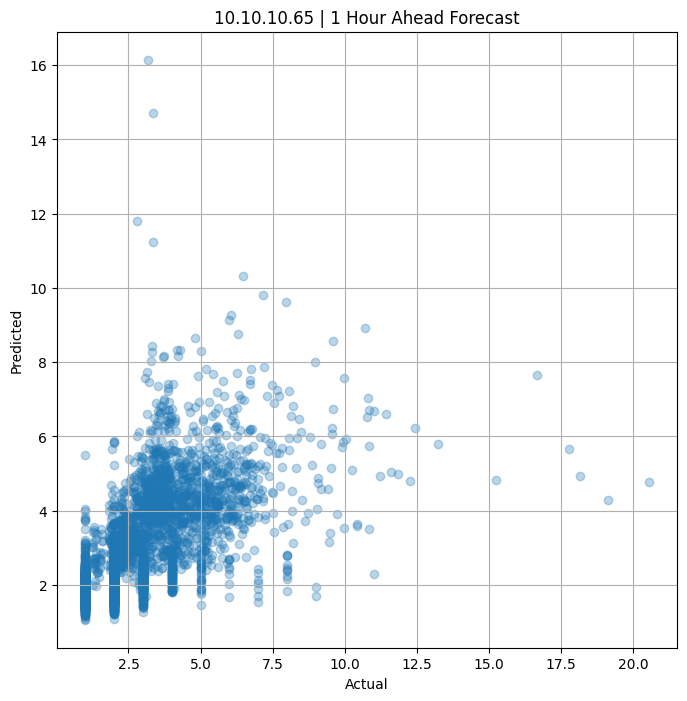

In [17]:
# Scatter plot
plt.figure(
    figsize=(8,8)
)
plt.scatter(
    actual_1hr,
    predicted_1hr,
    alpha=0.3
)
plt.xlabel(
    'Actual'
)
plt.ylabel(
    'Predicted'
)
plt.title(
    f'{SERVER_NAME} | 1 Hour Ahead Forecast'
)
plt.grid(True)
plt.show()

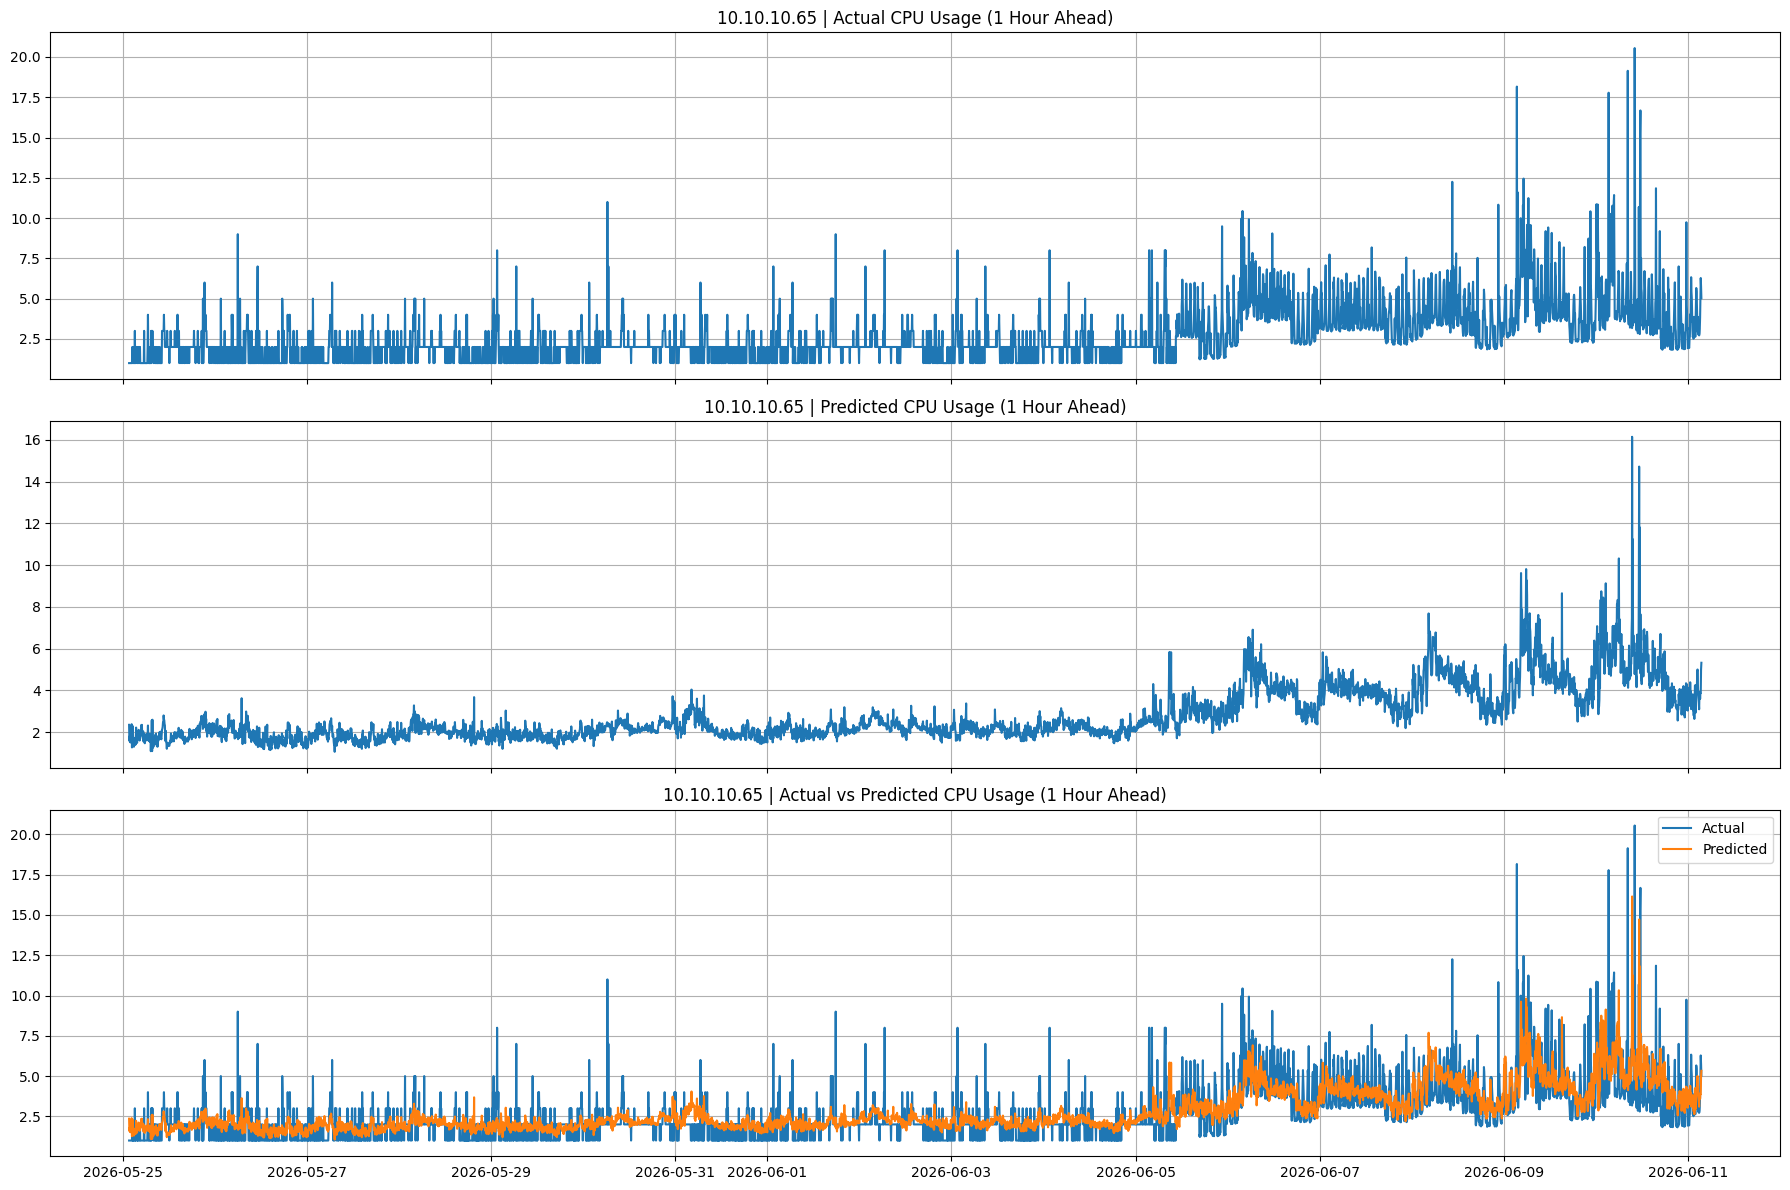

In [18]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(18,12),
    sharex=True
)
# Actual
axes[0].plot(
    results_1hr['Timestamp'],
    results_1hr['Actual_1hr']
)
axes[0].set_title(
    f'{SERVER_NAME} | Actual CPU Usage (1 Hour Ahead)'
)
axes[0].grid(True)

# Predicted
axes[1].plot(
    results_1hr['Timestamp'],
    results_1hr['Predicted_1hr']
)
axes[1].set_title(
    f'{SERVER_NAME} | Predicted CPU Usage (1 Hour Ahead)'
)
axes[1].grid(True)

# Combined
axes[2].plot(
    results_1hr['Timestamp'],
    results_1hr['Actual_1hr'],
    label='Actual'
)
axes[2].plot(
    results_1hr['Timestamp'],
    results_1hr['Predicted_1hr'],
    label='Predicted'
)
axes[2].set_title(
    f'{SERVER_NAME} | Actual vs Predicted CPU Usage (1 Hour Ahead)'
)

axes[2].legend()
axes[2].grid(True)
plt.tight_layout()
plt.show()

In [33]:
print(df.columns.tolist())

['id', 'ts', 'host_id', 'cpu_usage_pct', 'memory_usage_pct', 'power_kw', 'status', 'hostName', 'inlet_temp_c', 'cpu_temp_c', 'processor_count', 'status_encoded', 'cpu_lag_1', 'cpu_lag_2', 'cpu_change', 'cpu_roll_mean_3', 'cpu_acceleration', 'cpu_volatility', 'memory_lag_1', 'cpu_memory_ratio', 'power_roll_mean_12', 'thermal_gradient', 'temp_rate_of_change', 'temp_roll_mean_12', 'cpu_per_kw', 'temp_per_cpu', 'resource_stress_index', 'timestamp_display', 'hour_of_day', 'day_of_week', 'is_weekend', 'cpu_roll_mean_12', 'cpu_roll_mean_72', 'cpu_roll_mean_144', 'cpu_roll_std_144', 'cpu_trend_12h', 'cpu_lag_3', 'cpu_lag_4', 'cpu_lag_5', 'cpu_lag_6', 'cpu_lag_7', 'cpu_lag_8', 'cpu_lag_9', 'cpu_lag_10', 'cpu_lag_11', 'cpu_lag_12', 'cpu_lag_13', 'cpu_lag_14', 'cpu_lag_15', 'cpu_lag_16', 'cpu_lag_17', 'cpu_lag_18', 'cpu_lag_19', 'cpu_lag_20', 'cpu_lag_21', 'cpu_lag_22', 'cpu_lag_23', 'cpu_lag_24', 'cpu_lag_25', 'cpu_lag_26', 'cpu_lag_27', 'cpu_lag_28', 'cpu_lag_29', 'cpu_lag_30', 'cpu_lag_31', 'c

PREDICT NEXT 24 HOURS FROM THE PREVIOUS 24 HOURS

In [27]:
# choose starting point
# ==========================================
# Select a starting point inside test set
# ==========================================
START_IDX = 1000
history_row = test_df.iloc[START_IDX].copy()
print(history_row['ts'])

2026-05-28 12:59:17.463000+00:00


In [28]:
# create initial state
# ==========================================
# Create feature vector
# ==========================================
current_features = history_row[FEATURES].copy()
print(current_features.shape)

(160,)


In [29]:
# Recursive 24-hour forecast
# ==========================================
# Recursive Forecast
# ==========================================
future_predictions = []
FORECAST_HOURS = 24
for hour in range(FORECAST_HOURS):
    pred_1hr = multi_model.predict(
        pd.DataFrame([current_features])
    )[0]
    future_predictions.extend(
        pred_1hr.tolist()
    )
    # ----------------------------------
    # Update CPU Lag History
    # ----------------------------------
    lag_values = [
        current_features[f'cpu_lag_{i}']
        for i in range(
            1,
            HISTORY_WINDOW + 1
        )
    ]
    lag_values = (
        pred_1hr.tolist()
        +
        lag_values
    )
    lag_values = lag_values[:HISTORY_WINDOW]
    for i in range(
        1,
        HISTORY_WINDOW + 1
    ):
        current_features[
            f'cpu_lag_{i}'
        ] = lag_values[i-1]
    # ----------------------------------
    # Update Rolling Features
    # ----------------------------------
    cpu_series = np.array(
        lag_values
    )
    current_features[
        'cpu_roll_mean_12'
    ] = cpu_series[:12].mean()
    current_features[
        'cpu_roll_mean_72'
    ] = cpu_series[:72].mean()
    current_features[
        'cpu_roll_mean_144'
    ] = cpu_series[:144].mean()
    current_features[
        'cpu_roll_std_144'
    ] = cpu_series[:144].std()
    current_features[
        'cpu_trend_12h'
    ] = (
        cpu_series[0]
        -
        cpu_series[143]
    )

In [30]:
# Verify forecast length
print(len(future_predictions))

288


In [32]:
# Get actual future 24 hours
# ==========================================
# Actual CPU values
# ==========================================
actual_future = (
    df_multi['cpu_usage_pct']
    .iloc[
        START_IDX + 1 :
        START_IDX + 289
    ]
    .values
)
print(len(actual_future))

# get actual future timestamps
future_times = (
    df_multi['ts']
    .iloc[
        START_IDX + 1 :
        START_IDX + 289
    ]
    .values
)

# create comparision dataframe
comparison_24h = pd.DataFrame({
    'Timestamp':
        future_times,
    'Actual':
        actual_future,
    'Predicted':
        future_predictions
})
comparison_24h.head(10)

288


,Timestamp,Actual,Predicted
0,2026-04-04 02:53:18.080,6.0,2.143102
1,2026-04-04 02:55:20.321,4.0,2.314950
2,2026-04-04 02:57:17.978,4.0,2.882439
3,2026-04-04 02:59:19.205,6.0,2.201789
4,2026-04-04 03:01:21.577,4.0,2.355879
5,2026-04-04 03:03:17.727,4.0,2.291789
6,2026-04-04 03:05:18.374,6.0,2.304342
7,2026-04-04 03:07:25.793,4.0,2.622219
8,2026-04-04 03:09:19.438,4.0,2.161715
9,2026-04-04 03:11:17.797,6.0,2.098575


In [ ]:
# Metrics
mae_24h = mean_absolute_error(
    comparison_24h['Actual'],
    comparison_24h['Predicted']
)
rmse_24h = np.sqrt(
    mean_squared_error(
        comparison_24h['Actual'],
        comparison_24h['Predicted']
    )
)
r2_24h = r2_score(
    comparison_24h['Actual'],
    comparison_24h['Predicted']
)
print("24 Hour Forecast Metrics")
print("MAE :", mae_24h)
print("RMSE:", rmse_24h)
print("R²  :", r2_24h)

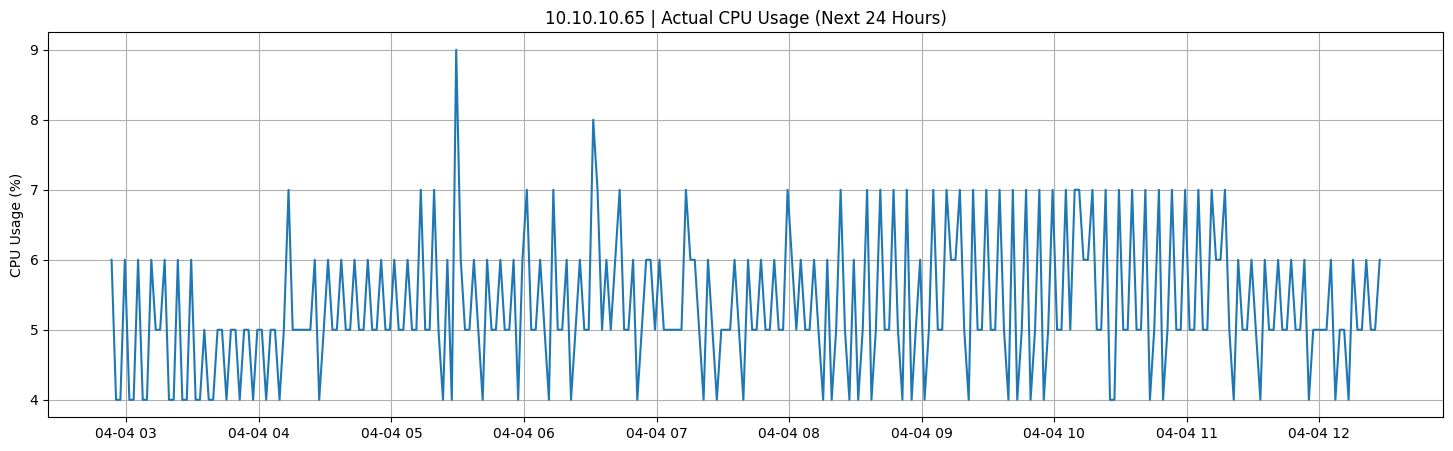

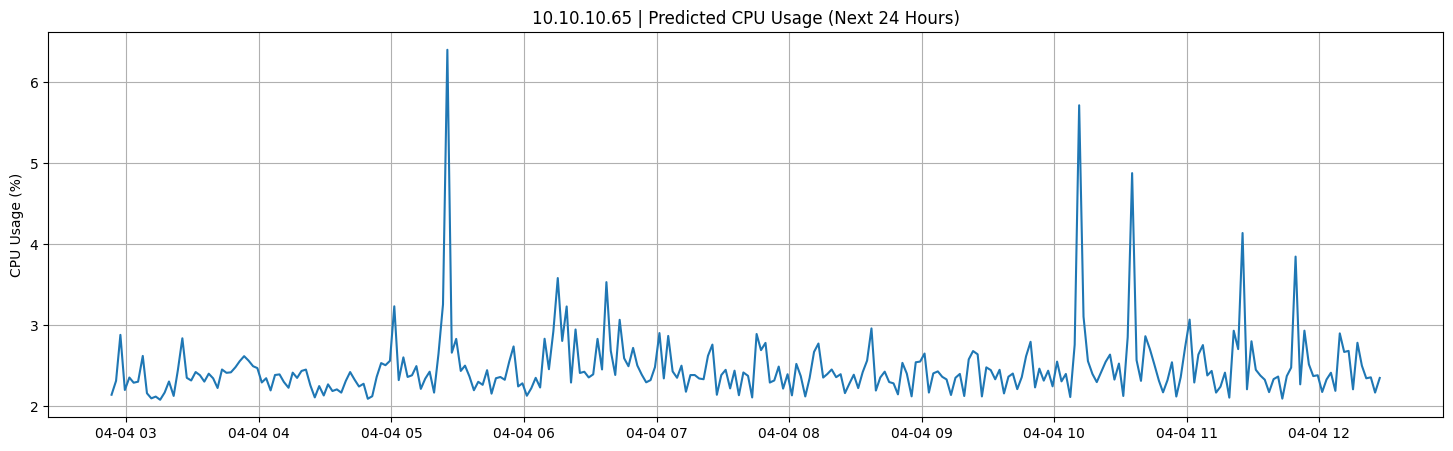

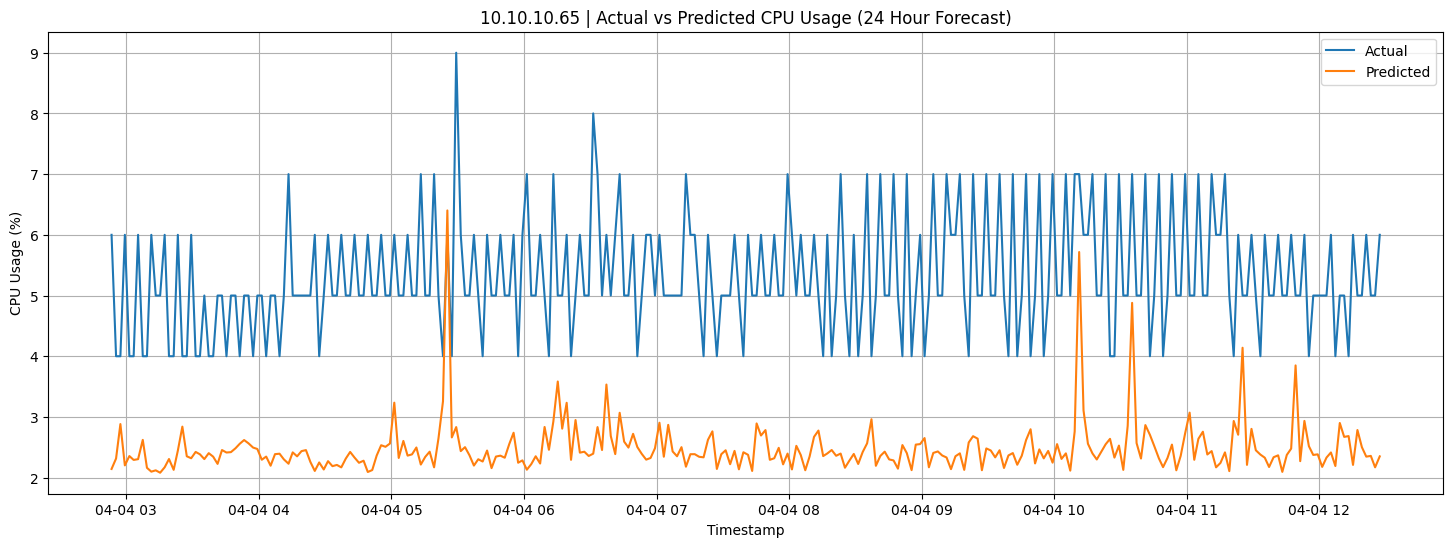

In [35]:
# Actual CPU Plot
plt.figure(
    figsize=(18,5)
)
plt.plot(
    comparison_24h['Timestamp'],
    comparison_24h['Actual']
)
plt.title(
    f'{SERVER_NAME} | Actual CPU Usage (Next 24 Hours)'
)
plt.ylabel(
    'CPU Usage (%)'
)
plt.grid(True)
plt.show()


# Predicted CPU PLOT
plt.figure(
    figsize=(18,5)
)
plt.plot(
    comparison_24h['Timestamp'],
    comparison_24h['Predicted']
)
plt.title(
    f'{SERVER_NAME} | Predicted CPU Usage (Next 24 Hours)'
)
plt.ylabel(
    'CPU Usage (%)'
)
plt.grid(True)
plt.show()


# Actual vs Predicted
plt.figure(
    figsize=(18,6)
)
plt.plot(
    comparison_24h['Timestamp'],
    comparison_24h['Actual'],
    label='Actual'
)
plt.plot(
    comparison_24h['Timestamp'],
    comparison_24h['Predicted'],
    label='Predicted'
)
plt.title(
    f'{SERVER_NAME} | Actual vs Predicted CPU Usage (24 Hour Forecast)'
)
plt.ylabel(
    'CPU Usage (%)'
)
plt.xlabel(
    'Timestamp'
)
plt.legend()
plt.grid(True)
plt.show()

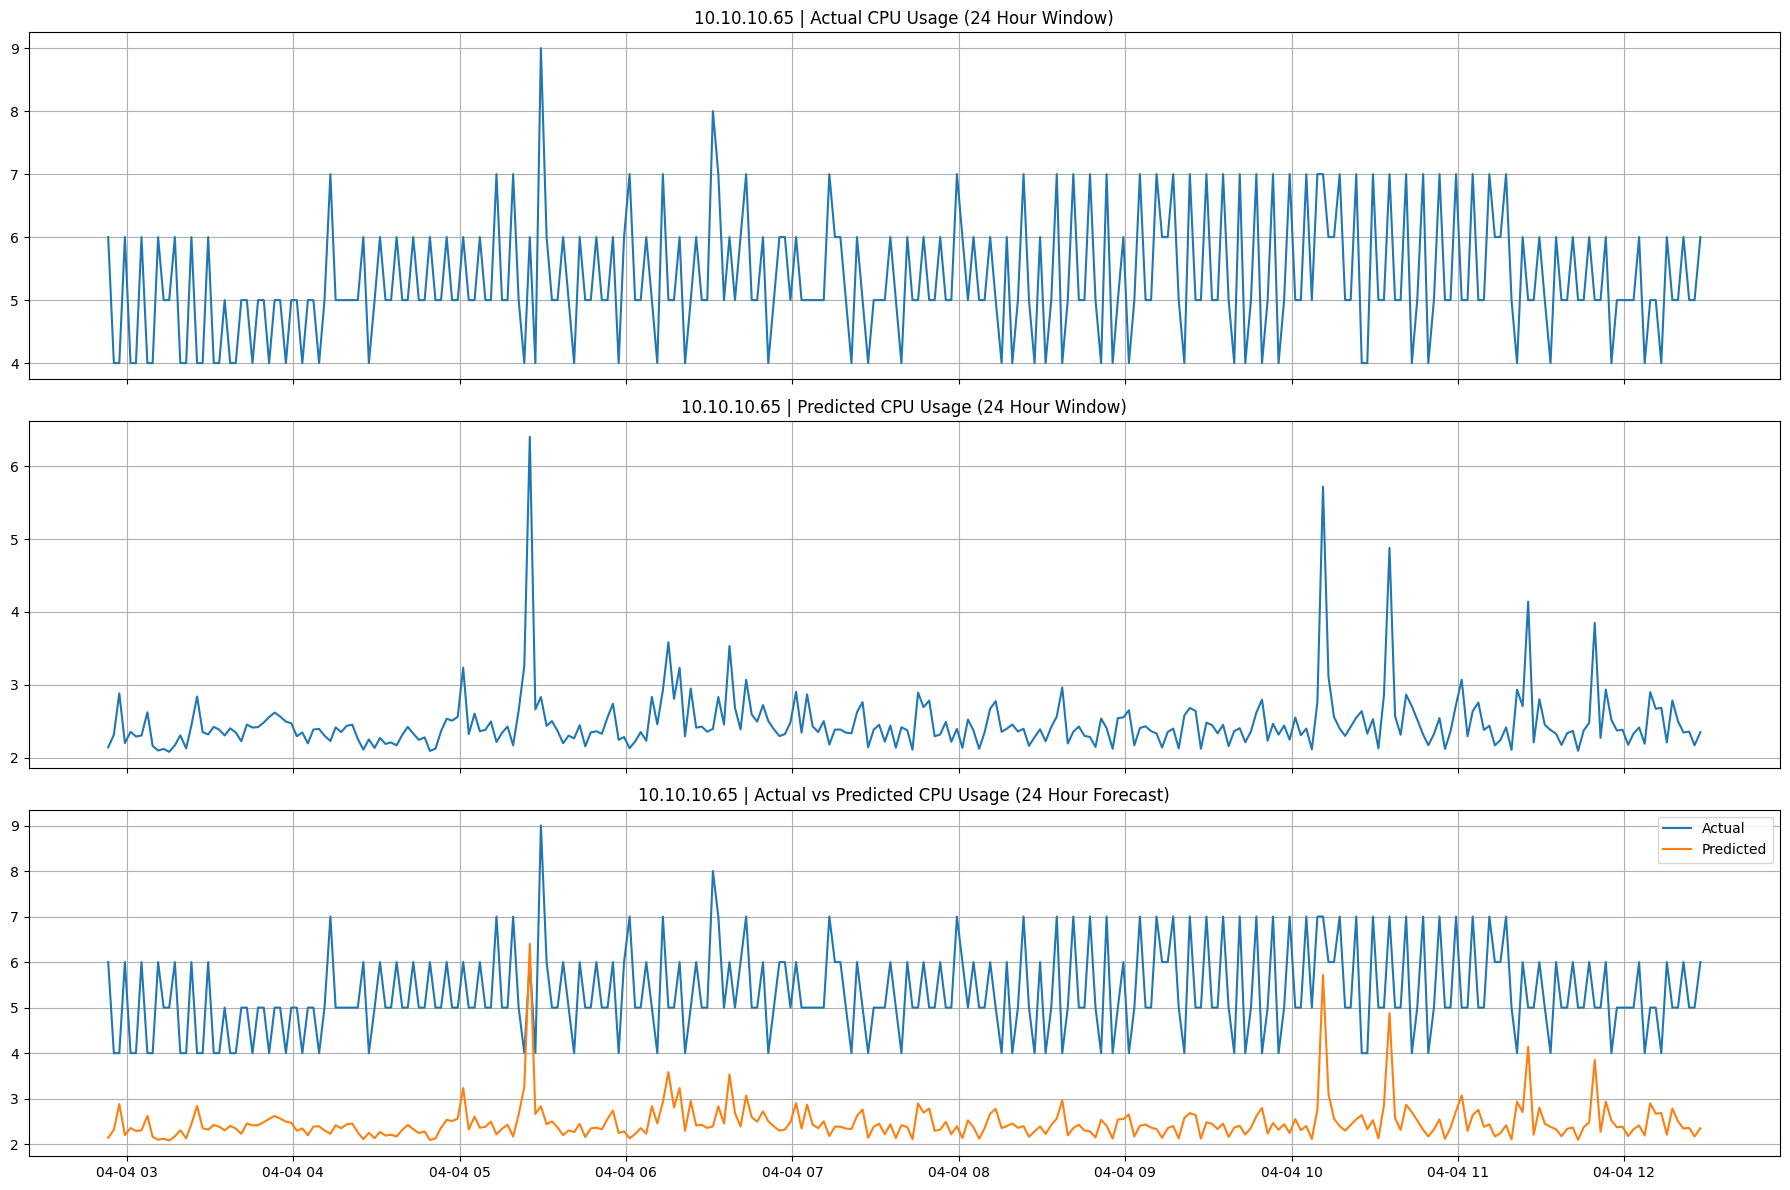

In [36]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(18,12),
    sharex=True
)

# Actual

axes[0].plot(
    comparison_24h['Timestamp'],
    comparison_24h['Actual']
)

axes[0].set_title(
    f'{SERVER_NAME} | Actual CPU Usage (24 Hour Window)'
)

axes[0].grid(True)

# Predicted

axes[1].plot(
    comparison_24h['Timestamp'],
    comparison_24h['Predicted']
)

axes[1].set_title(
    f'{SERVER_NAME} | Predicted CPU Usage (24 Hour Window)'
)

axes[1].grid(True)

# Combined

axes[2].plot(
    comparison_24h['Timestamp'],
    comparison_24h['Actual'],
    label='Actual'
)

axes[2].plot(
    comparison_24h['Timestamp'],
    comparison_24h['Predicted'],
    label='Predicted'
)

axes[2].set_title(
    f'{SERVER_NAME} | Actual vs Predicted CPU Usage (24 Hour Forecast)'
)

axes[2].legend()

axes[2].grid(True)

plt.tight_layout()

plt.show()